In [1]:
import torch
from torch import nn
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, train_transforms, val_transforms

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=train_transforms
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=val_transforms
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARBaseline
from src.metrics import create_metrics
from src.engine import fit

model = CIFARBaseline().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)
epochs = 10

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation.pt'
)

history


Epoch 1/10:
Training Loss: 1.6661 | Training Accuracy: 38.08% | Training Precision: 37.40% | Training Recall: 38.08%
Validation Loss: 1.3437 | Validation Accuracy: 51.00% | Validation Precision: 53.42% | Validation Recall: 51.00%
Best model saved! Val Acc: 51.00%

Epoch 2/10:
Training Loss: 1.2479 | Training Accuracy: 54.76% | Training Precision: 54.24% | Training Recall: 54.76%
Validation Loss: 1.0518 | Validation Accuracy: 62.48% | Validation Precision: 63.93% | Validation Recall: 62.48%
Best model saved! Val Acc: 62.48%

Epoch 3/10:
Training Loss: 1.0393 | Training Accuracy: 62.81% | Training Precision: 62.54% | Training Recall: 62.81%
Validation Loss: 0.9019 | Validation Accuracy: 67.70% | Validation Precision: 69.54% | Validation Recall: 67.70%
Best model saved! Val Acc: 67.70%

Epoch 4/10:
Training Loss: 0.9267 | Training Accuracy: 67.22% | Training Precision: 66.96% | Training Recall: 67.22%
Validation Loss: 0.8235 | Validation Accuracy: 71.20% | Validation Precision: 72.07% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.666109,0.380825,0.373969,0.380825,1.343705,0.5100,0.534242,0.5100
1,2,1.247931,0.547650,0.542437,0.547650,1.051773,0.6248,0.639262,0.6248
2,3,1.039317,0.628125,0.625375,0.628125,0.901926,0.6770,0.695366,0.6770
3,4,0.926708,0.672150,0.669560,0.672150,0.823531,0.7120,0.720737,0.7120
4,5,0.843654,0.703825,0.702176,0.703825,0.746907,0.7420,0.743652,0.7420
5,6,0.796416,0.721000,0.719676,0.721000,0.721021,0.7472,0.754396,0.7472
6,7,0.754321,0.738250,0.737440,0.738250,0.698220,0.7588,0.761821,0.7588
7,8,0.720305,0.747300,0.746188,0.747300,0.740160,0.7444,0.758724,0.7444
8,9,0.686158,0.759200,0.758588,0.759200,0.673054,0.7672,0.774937,0.7672
9,10,0.667176,0.767875,0.767059,0.767875,0.673921,0.7670,0.772480,0.7670


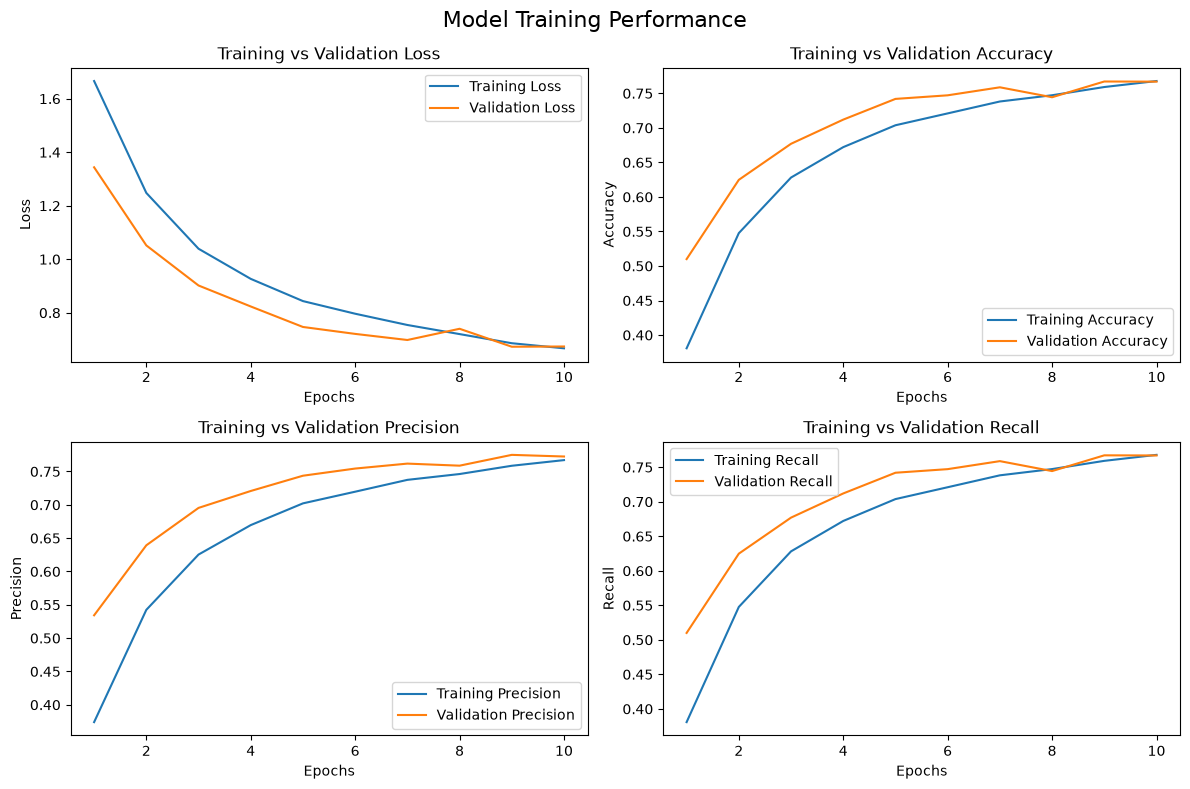

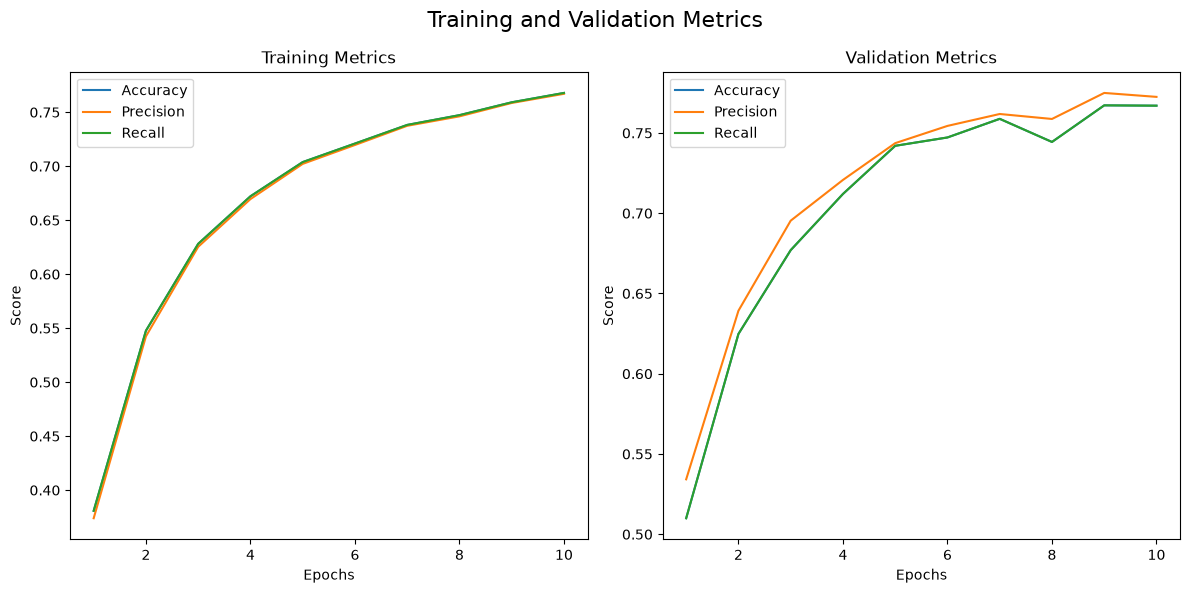

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)